# Filtro visual: Convoluciones personalizadas

## 1. Importar librerías

In [4]:
import os

import cv2
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "data"
OUTPUT_DIR = os.path.join("..", "media")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2. Cargar imagen en escala de grises

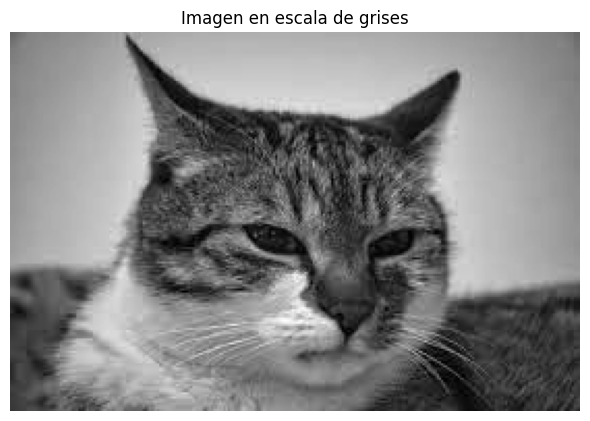

In [5]:
IMAGE_PATH = os.path.join(DATA_DIR, "input.jpg")

if not os.path.exists(IMAGE_PATH):
    raise FileNotFoundError(
        "No se encontro la imagen local. "
        "Copia una imagen en data/input.jpg y vuelve a ejecutar esta celda."
    )

img_bgr = cv2.imread(IMAGE_PATH, cv2.IMREAD_COLOR)
if img_bgr is None:
    raise FileNotFoundError(f"No se pudo cargar la imagen: {IMAGE_PATH}")

img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)

plt.figure(figsize=(6, 6))
plt.imshow(img_gray, cmap="gray")
plt.title("Imagen en escala de grises")
plt.axis("off")
plt.tight_layout()
plt.show()

## 3. Utilidades de visualización

In [6]:
def to_uint8(img):
    img = img.astype(np.float32)
    if np.isclose(img.max(), img.min()):
        return np.zeros_like(img, dtype=np.uint8)
    img_norm = (img - img.min()) / (img.max() - img.min())
    return (img_norm * 255).astype(np.uint8)


def show_row(images, titles, cmap="gray", figsize=(16, 5)):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    if len(images) == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## 4. Convolución 2D manual

In [7]:
def convolve2d_gray(image, kernel, padding="reflect"):
    kernel = np.flipud(np.fliplr(kernel))
    kh, kw = kernel.shape
    pad_h = kh // 2
    pad_w = kw // 2

    if padding == "reflect":
        padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode="reflect")
    elif padding == "zero":
        padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode="constant")
    else:
        raise ValueError("padding debe ser 'reflect' o 'zero'")

    out = np.zeros_like(image, dtype=np.float32)
    h, w = image.shape

    for y in range(h):
        for x in range(w):
            region = padded[y : y + kh, x : x + kw]
            out[y, x] = np.sum(region * kernel)

    return out

## 5. Definir kernels personalizados

In [8]:
kernel_blur = np.array(
    [
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1],
    ],
    dtype=np.float32,
) / 9.0

kernel_sharpen = np.array(
    [
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0],
    ],
    dtype=np.float32,
)

sobel_x = np.array(
    [
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1],
    ],
    dtype=np.float32,
)

sobel_y = np.array(
    [
        [-1, -2, -1],
        [0, 0, 0],
        [1, 2, 1],
    ],
    dtype=np.float32,
)

## 6. Aplicar filtros con convolución manual

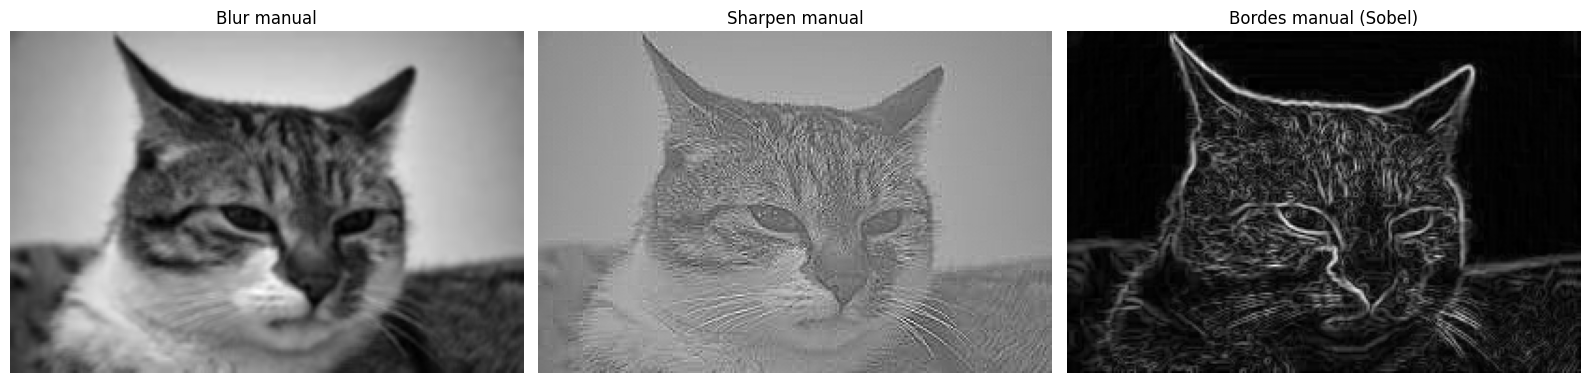

In [9]:
blur_manual = convolve2d_gray(img_gray, kernel_blur)
sharpen_manual = convolve2d_gray(img_gray, kernel_sharpen)

ix_manual = convolve2d_gray(img_gray, sobel_x)
iy_manual = convolve2d_gray(img_gray, sobel_y)
edges_manual = np.hypot(ix_manual, iy_manual)

show_row(
    [to_uint8(blur_manual), to_uint8(sharpen_manual), to_uint8(edges_manual)],
    ["Blur manual", "Sharpen manual", "Bordes manual (Sobel)"],
)

## 7. Comparar con OpenCV (filter2D y Sobel)

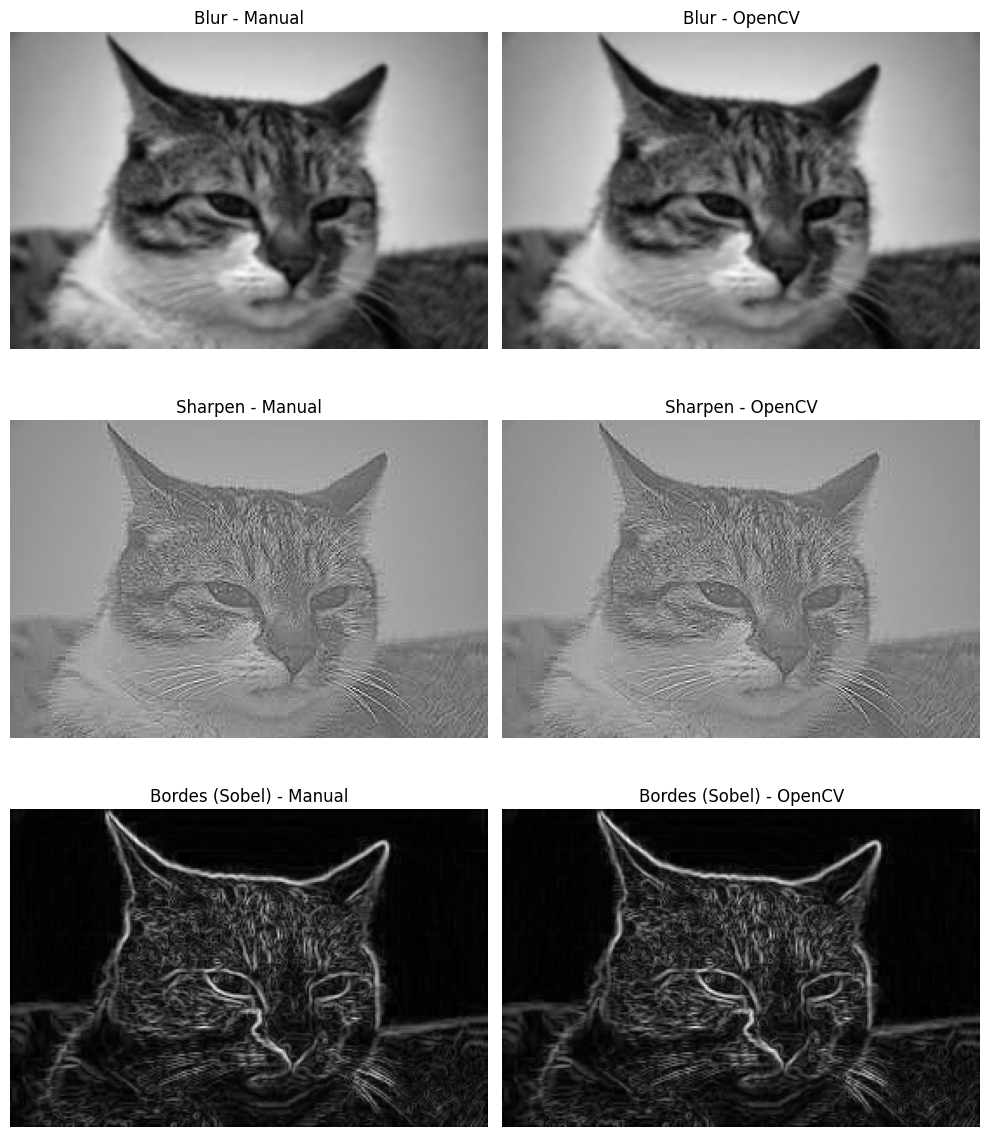

In [10]:
blur_cv = cv2.filter2D(img_gray, ddepth=-1, kernel=kernel_blur)
sharpen_cv = cv2.filter2D(img_gray, ddepth=-1, kernel=kernel_sharpen)

ix_cv = cv2.Sobel(img_gray, cv2.CV_32F, 1, 0, ksize=3)
iy_cv = cv2.Sobel(img_gray, cv2.CV_32F, 0, 1, ksize=3)
edges_cv = np.hypot(ix_cv, iy_cv)

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
pairs = [
    (blur_manual, blur_cv, "Blur"),
    (sharpen_manual, sharpen_cv, "Sharpen"),
    (edges_manual, edges_cv, "Bordes (Sobel)"),
]

for row, (manual_img, cv_img, title) in enumerate(pairs):
    axes[row, 0].imshow(to_uint8(manual_img), cmap="gray")
    axes[row, 0].set_title(f"{title} - Manual")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(to_uint8(cv_img), cmap="gray")
    axes[row, 1].set_title(f"{title} - OpenCV")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

## 8. Detección de esquinas (Sobel + derivadas cruzadas)

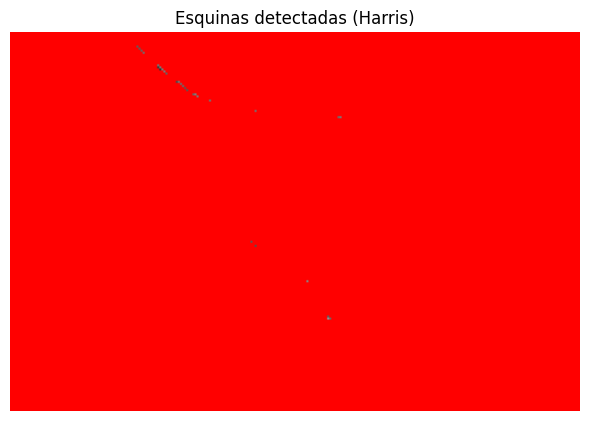

In [11]:
Ixx = ix_manual * ix_manual
Iyy = iy_manual * iy_manual
Ixy = ix_manual * iy_manual

Sxx = convolve2d_gray(Ixx, kernel_blur)
Syy = convolve2d_gray(Iyy, kernel_blur)
Sxy = convolve2d_gray(Ixy, kernel_blur)

k = 0.04
det = (Sxx * Syy) - (Sxy * Sxy)
trace = Sxx + Syy
R = det - k * (trace * trace)

R_norm = (R - R.min()) / (R.max() - R.min())
corners = R_norm > 0.1

img_corners = cv2.cvtColor(to_uint8(img_gray), cv2.COLOR_GRAY2BGR)
img_corners[corners] = [0, 0, 255]

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img_corners, cv2.COLOR_BGR2RGB))
plt.title("Esquinas detectadas (Harris)")
plt.axis("off")
plt.tight_layout()
plt.show()